In [1]:
# =========================
# 0. 套件
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.unicode_minus"] = False


# =========================
# 1. 檔案路徑
# =========================
TMEAN_FILE = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmean_corrected_daily_final_models.parquet"
TMAX_FILE  = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmax_corrected_daily_final_models.parquet"
TMIN_FILE  = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\qm_corrected_output\tmin_corrected_daily_final_models.parquet"

START_YEAR = 2004
END_YEAR = 2036

SCENARIO_ORDER = ["rcp26", "rcp45", "rcp60", "rcp85"]
SCENARIO_LABELS = {
    "rcp26": "RCP2.6",
    "rcp45": "RCP4.5",
    "rcp60": "RCP6.0",
    "rcp85": "RCP8.5",
}

SEASON_ORDER = ["Spring", "Summer", "Autumn", "Winter"]

SCENARIO_COLORS = {
    "rcp26": "#45b66f",  # green
    "rcp45": "#d4b12a",  # yellow-gold
    "rcp60": "#cf8439",  # orange-brown
    "rcp85": "#d25d4d",  # red
}


# 輸出資料夾
OUTPUT_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")#"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. 讀檔函式
# =========================
def read_one_variable_parquet(fp, variable_name):
    fp = Path(fp)
    if not fp.exists():
        raise FileNotFoundError(f"找不到檔案：{fp}")

    df = pd.read_parquet(fp).copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df["scenario"] = df["scenario"].astype(str).str.lower()
    df["model"] = df["model"].astype(str)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["variable"] = variable_name

    df = df[
        (df["year"] >= START_YEAR) &
        (df["year"] <= END_YEAR)
    ].copy()

    df = df.dropna(subset=["date", "value", "scenario", "model"]).copy()
    df = df.drop_duplicates(subset=["scenario", "model", "date"]).copy()
    return df

# =========================
# 3. 季節定義
# =========================
def month_to_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return "Winter"

# =========================
# 3. 讀三個變數
# =========================
tmean_df = read_one_variable_parquet(TMEAN_FILE, "tmean")
tmax_df  = read_one_variable_parquet(TMAX_FILE,  "tmax")
tmin_df  = read_one_variable_parquet(TMIN_FILE,  "tmin")

for _df in [tmean_df, tmax_df, tmin_df]:
    _df["season"] = _df["month"].apply(month_to_season)


print("tmean:", tmean_df.shape)
print("tmax :", tmax_df.shape)
print("tmin :", tmin_df.shape)

print("\nscenarios in tmean:", sorted(tmean_df["scenario"].unique()))
print("scenarios in tmax :", sorted(tmax_df["scenario"].unique()))
print("scenarios in tmin :", sorted(tmin_df["scenario"].unique()))

tmean: (1063610, 8)
tmax : (1063610, 8)
tmin : (1063610, 8)

scenarios in tmean: ['historical', 'rcp26', 'rcp45', 'rcp60', 'rcp85']
scenarios in tmax : ['historical', 'rcp26', 'rcp45', 'rcp60', 'rcp85']
scenarios in tmin : ['historical', 'rcp26', 'rcp45', 'rcp60', 'rcp85']


In [2]:
# =========================
# 4. 溫度組合定義
# =========================
combo_defs = [
    {"title": "Tmax_26_to_29C", "df_name": "tmax",  "lower": 26.0, "upper": 29.0},
    {"title": "Tmean_28_to_31C", "df_name": "tmean", "lower": 28.0, "upper": 31.0},
    {"title": "Tmin_20_to_25C", "df_name": "tmin",  "lower": 20.0, "upper": 25.0},
    {"title": "Tmin_ge15_9C",   "df_name": "tmin",  "lower": 15.9, "upper": None},
]

# =========================
# 5. 建立資料字典
# =========================
df_map = {
    "tmean": tmean_df,
    "tmax": tmax_df,
    "tmin": tmin_df,
}


In [3]:
# =========================
# 7. 計算單一溫度組合的 seasonal slopes
# 回傳：
#   slope_mean_df: 每個 scenario-season 的平均 slope
#   model_slope_df: 每個 model 的 slope（之後如果要畫 boxplot 會用到）
# =========================
def calc_seasonal_slopes_for_combo(combo, df_map):
    df = df_map[combo["df_name"]].copy()

    # 溫度條件
    if combo["upper"] is None:
        mask = df["value"] >= combo["lower"]
    else:
        mask = (df["value"] >= combo["lower"]) & (df["value"] < combo["upper"])

    df = df[mask].copy()

    # 算每個 scenario / model / year / season 的日數
    counts = (
        df.groupby(["scenario", "model", "year", "season"], as_index=False)
          .size()
          .rename(columns={"size": "count"})
    )

    # 補齊所有年份與季節，沒出現的補 0
    all_years = np.arange(START_YEAR, END_YEAR + 1)

    full_rows = []
    for scenario in SCENARIO_ORDER:
        sub_sc = counts[counts["scenario"] == scenario].copy()
        if sub_sc.empty:
            continue

        for model in sorted(sub_sc["model"].unique()):
            for season in SEASON_ORDER:
                g = sub_sc[
                    (sub_sc["model"] == model) &
                    (sub_sc["season"] == season)
                ][["year", "count"]].copy()

                g = g.set_index("year").reindex(all_years, fill_value=0).reset_index()
                g.columns = ["year", "count"]
                g["scenario"] = scenario
                g["model"] = model
                g["season"] = season
                full_rows.append(g)

    counts_full = pd.concat(full_rows, ignore_index=True)

    # 每個 model 的 slope
    model_slope_rows = []
    for (scenario, model, season), g in counts_full.groupby(["scenario", "model", "season"]):
        g = g.sort_values("year")

        if len(g) < 2:
            slope = np.nan
        else:
            slope, _ = np.polyfit(g["year"], g["count"], 1)

        model_slope_rows.append({
            "scenario": scenario,
            "model": model,
            "season": season,
            "slope": slope
        })

    model_slope_df = pd.DataFrame(model_slope_rows)

    # 對所有 model 的 slope 取平均
    slope_mean_df = (
        model_slope_df.groupby(["scenario", "season"], as_index=False)["slope"]
                      .mean()
    )

    return slope_mean_df, model_slope_df



=== Tmax_26_to_29C ===
   scenario  season     slope
0     rcp26  Autumn  0.195371
1     rcp26  Spring  0.163068
2     rcp26  Summer -0.069987
3     rcp26  Winter  0.107921
4     rcp45  Autumn  0.214671
5     rcp45  Spring  0.163300
6     rcp45  Summer -0.016550
7     rcp45  Winter  0.072613
8     rcp60  Autumn  0.147148
9     rcp60  Spring  0.169541
10    rcp60  Summer  0.036898
11    rcp60  Winter  0.080348
12    rcp85  Autumn  0.194953
13    rcp85  Spring  0.150925
14    rcp85  Summer  0.086319
15    rcp85  Winter  0.060717


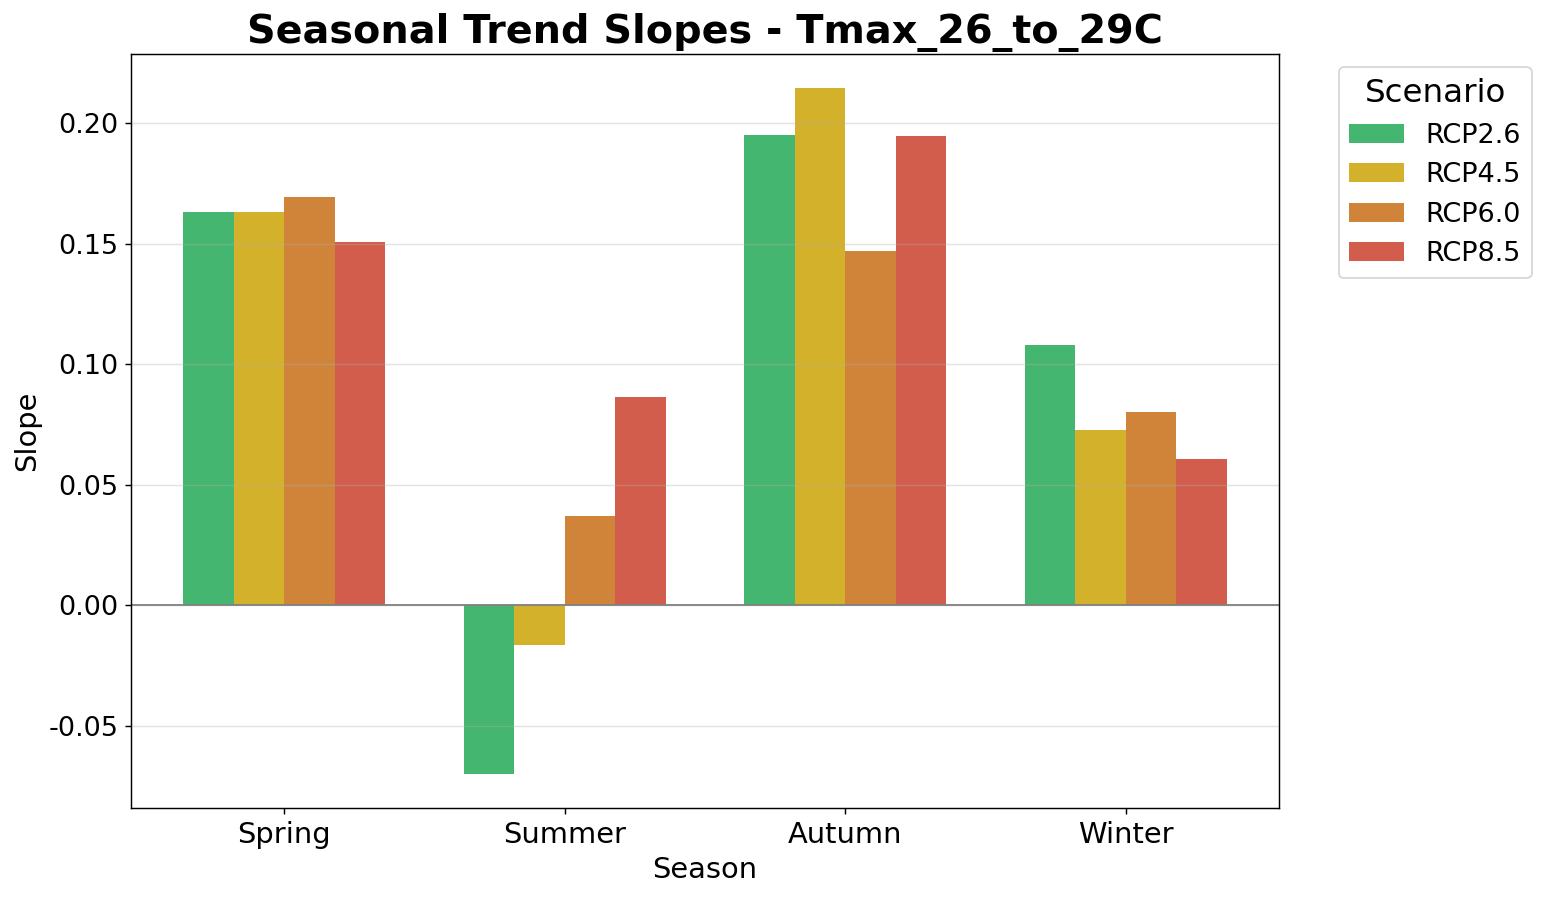


=== Tmean_28_to_31C ===
   scenario  season     slope
0     rcp26  Autumn  0.408205
1     rcp26  Spring  0.288369
2     rcp26  Summer  0.929612
3     rcp26  Winter  0.000602
4     rcp45  Autumn  0.340290
5     rcp45  Spring  0.289624
6     rcp45  Summer  0.826290
7     rcp45  Winter -0.000099
8     rcp60  Autumn  0.290530
9     rcp60  Spring  0.192781
10    rcp60  Summer  0.740909
11    rcp60  Winter  0.000000
12    rcp85  Autumn  0.309392
13    rcp85  Spring  0.194463
14    rcp85  Summer  0.724788
15    rcp85  Winter  0.000134


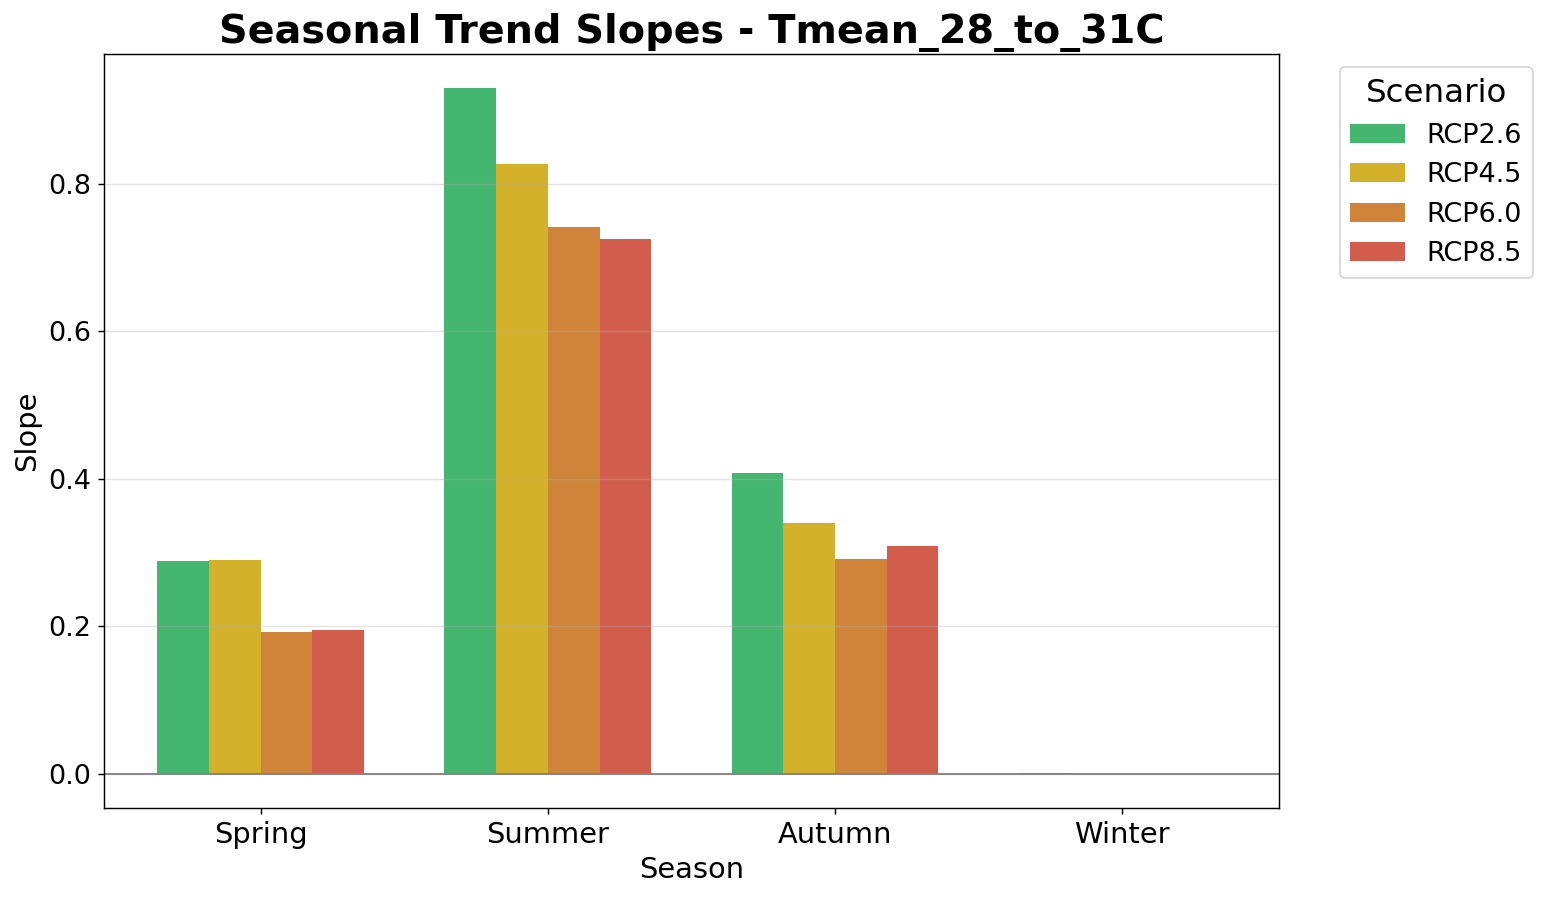


=== Tmin_20_to_25C ===
   scenario  season     slope
0     rcp26  Autumn  0.388035
1     rcp26  Spring  0.490558
2     rcp26  Summer -0.199482
3     rcp26  Winter  0.098780
4     rcp45  Autumn  0.427003
5     rcp45  Spring  0.466268
6     rcp45  Summer -0.138592
7     rcp45  Winter  0.061275
8     rcp60  Autumn  0.452874
9     rcp60  Spring  0.436074
10    rcp60  Summer  0.077629
11    rcp60  Winter  0.064684
12    rcp85  Autumn  0.403710
13    rcp85  Spring  0.454267
14    rcp85  Summer -0.070833
15    rcp85  Winter  0.089405


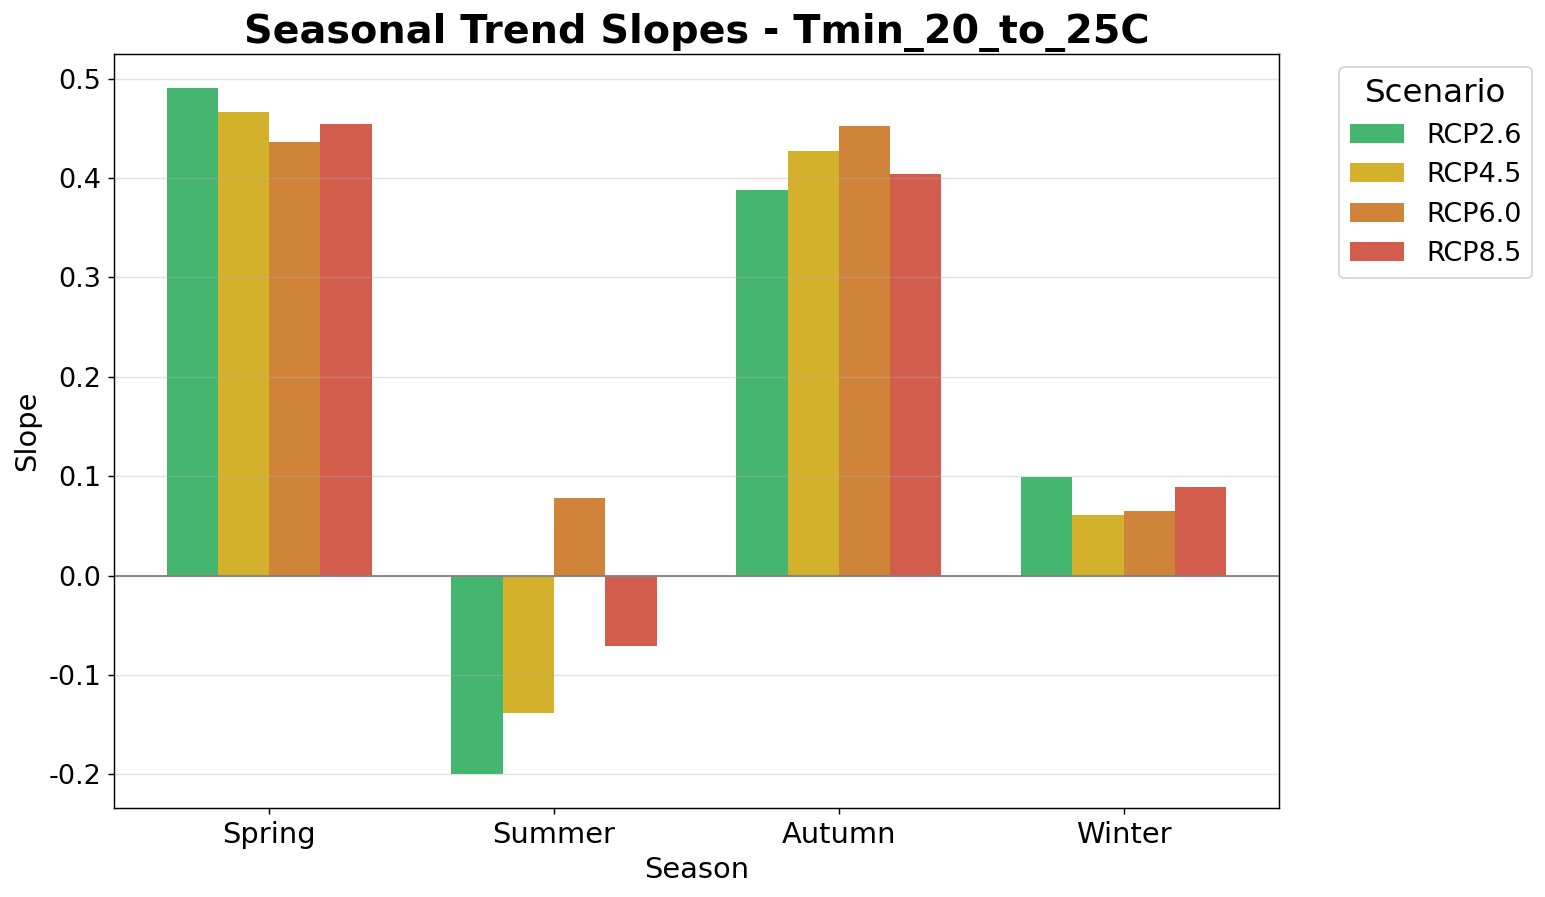


=== Tmin_ge15_9C ===
   scenario  season     slope
0     rcp26  Autumn  0.948630
1     rcp26  Spring  0.867062
2     rcp26  Summer  0.954462
3     rcp26  Winter  0.633606
4     rcp45  Autumn  0.945732
5     rcp45  Spring  0.848968
6     rcp45  Summer  0.953815
7     rcp45  Winter  0.583408
8     rcp60  Autumn  0.930749
9     rcp60  Spring  0.830949
10    rcp60  Summer  0.953231
11    rcp60  Winter  0.542692
12    rcp85  Autumn  0.939149
13    rcp85  Spring  0.824376
14    rcp85  Summer  0.953209
15    rcp85  Winter  0.620131


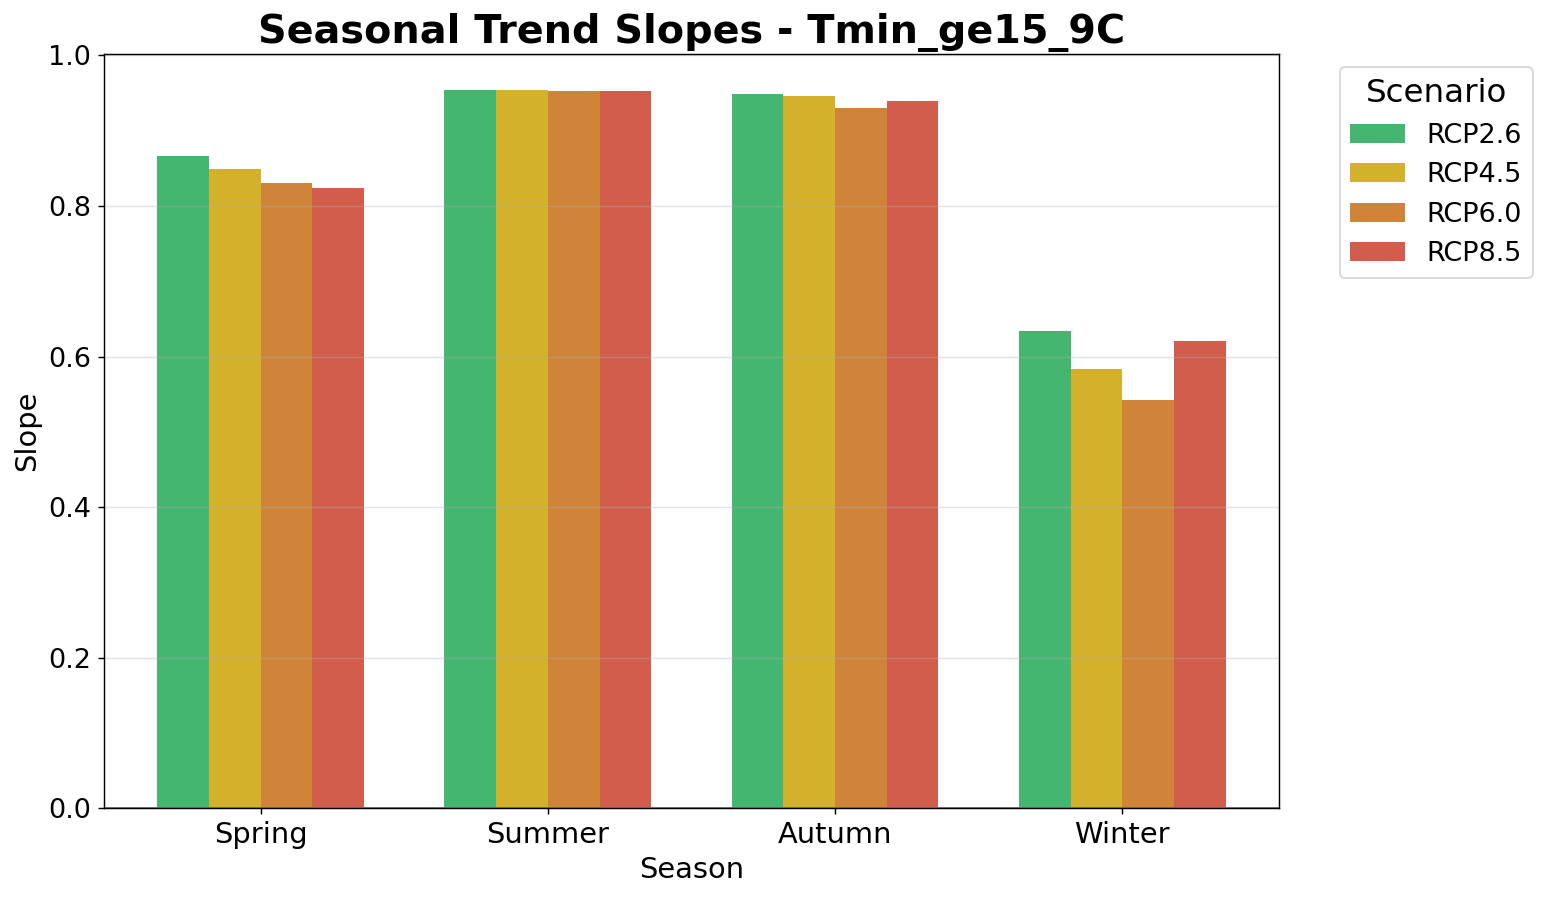

In [4]:
# =========================
# 8. 畫單一溫度組合的圖
# =========================
def plot_seasonal_slope_bars(slope_mean_df, combo_title):
    # 補齊 scenario-season 組合，避免有缺漏
    full_grid = pd.MultiIndex.from_product(
        [SCENARIO_ORDER, SEASON_ORDER],
        names=["scenario", "season"]
    ).to_frame(index=False)

    slope_plot_df = full_grid.merge(
        slope_mean_df,
        on=["scenario", "season"],
        how="left"
    ).fillna({"slope": 0})

    # x 位置
    x = np.arange(len(SEASON_ORDER))
    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 7))

    offsets = {
        "rcp26": -1.5 * width,
        "rcp45": -0.5 * width,
        "rcp60":  0.5 * width,
        "rcp85":  1.5 * width,
    }

    for scenario in SCENARIO_ORDER:
        sub = slope_plot_df[slope_plot_df["scenario"] == scenario].copy()
        sub["season"] = pd.Categorical(sub["season"], categories=SEASON_ORDER, ordered=True)
        sub = sub.sort_values("season")

        ax.bar(
            x + offsets[scenario],
            sub["slope"].values,
            width=width,
            label=SCENARIO_LABELS[scenario],
            color=SCENARIO_COLORS[scenario]
        )

    ax.set_xticks(x)
    ax.set_xticklabels(SEASON_ORDER, fontsize=16)
    ax.set_ylabel("Slope", fontsize=16)
    ax.set_xlabel("Season", fontsize=16)
    ax.set_title(f"Seasonal Trend Slopes - {combo_title}", fontsize=22, weight="bold")
    ax.axhline(0, color="gray", linewidth=1)

    ax.legend(title="Scenario", fontsize=15, title_fontsize=18,
              bbox_to_anchor=(1.04, 1), loc="upper left")

    ax.tick_params(axis="y", labelsize=15)
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    outpath = OUTPUT_DIR / f"Seasonal Trend Slopes - {combo_title}.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()


# =========================
# 9. 跑所有溫度組合
# =========================
all_results = {}

for combo in combo_defs:
    slope_mean_df, model_slope_df = calc_seasonal_slopes_for_combo(combo, df_map)
    all_results[combo["title"]] = {
        "slope_mean_df": slope_mean_df,
        "model_slope_df": model_slope_df,
    }

    print(f"\n=== {combo['title']} ===")
    print(slope_mean_df)

    plot_seasonal_slope_bars(slope_mean_df, combo["title"])

In [22]:
# =========================
# 6. 計算每年日數
# =========================
all_counts = []

for combo in combo_defs:
    sub = df_map[combo["df_name"]].copy()

    if combo["upper"] is None:
        mask = sub["value"] >= combo["lower"]
    else:
        mask = (sub["value"] >= combo["lower"]) & (sub["value"] < combo["upper"])

    sub = sub[mask].copy()

    annual = (
        sub.groupby(["scenario", "model", "year"], as_index=False)
           .size()
           .rename(columns={"size": "count"})
    )

    annual["title"] = combo["title"]
    all_counts.append(annual)

annual_counts = pd.concat(all_counts, ignore_index=True)

print(annual_counts)
print(annual_counts.shape)

         scenario      model  year  count           title
0      historical  ACCESS1-0  2004     44  Tmax_26_to_29C
1      historical  ACCESS1-0  2005     48  Tmax_26_to_29C
2      historical  ACCESS1-3  2004     46  Tmax_26_to_29C
3      historical  ACCESS1-3  2005     49  Tmax_26_to_29C
4      historical    BNU-ESM  2004     41  Tmax_26_to_29C
...           ...        ...   ...    ...             ...
11651       rcp85     inmcm4  2032    251    Tmin_ge15_9C
11652       rcp85     inmcm4  2033    284    Tmin_ge15_9C
11653       rcp85     inmcm4  2034    288    Tmin_ge15_9C
11654       rcp85     inmcm4  2035    283    Tmin_ge15_9C
11655       rcp85     inmcm4  2036    276    Tmin_ge15_9C

[11656 rows x 5 columns]
(11656, 5)


In [24]:
# =========================
# 7. 補齊所有年份（沒出現的補 0）
# =========================
all_years = np.arange(START_YEAR, END_YEAR + 1)

full_rows = []

for combo in annual_counts["title"].unique():
    sub_combo = annual_counts[annual_counts["title"] == combo].copy()

    for scenario in sorted(sub_combo["scenario"].unique()):
        sub_sc = sub_combo[sub_combo["scenario"] == scenario].copy()

        for model in sorted(sub_sc["model"].unique()):
            g = sub_sc[sub_sc["model"] == model][["year", "count"]].copy()

            g = (
                g.set_index("year")
                 .reindex(all_years, fill_value=0)
                 .reset_index()
            )

            g.columns = ["year", "count"]
            g["combo"] = combo
            g["scenario"] = scenario
            g["model"] = model

            full_rows.append(g)

annual_counts_full = pd.concat(full_rows, ignore_index=True)

print(annual_counts_full.head())
print(annual_counts_full.shape)


   year  count           combo    scenario      model
0  2004     44  Tmax_26_to_29C  historical  ACCESS1-0
1  2005     48  Tmax_26_to_29C  historical  ACCESS1-0
2  2006      0  Tmax_26_to_29C  historical  ACCESS1-0
3  2007      0  Tmax_26_to_29C  historical  ACCESS1-0
4  2008      0  Tmax_26_to_29C  historical  ACCESS1-0
(16236, 5)


In [28]:
# =========================
# 8. 計算 ensemble mean 與 slope
# =========================
ensemble_counts = (
    annual_counts_full.groupby(["combo", "scenario", "year"], as_index=False)["count"]
                      .mean()
                      .rename(columns={"count": "ensemble_mean_count"})
)

slope_rows = []

for (combo, scenario), g in ensemble_counts.groupby(["combo", "scenario"]):
    g = g.sort_values("year")

    if len(g) < 2:
        slope = np.nan
    else:
        slope, intercept = np.polyfit(g["year"], g["ensemble_mean_count"], 1)

    slope_rows.append({
        "combo": combo,
        "scenario": scenario,
        "slope_days_per_year": slope
    })

slope_df = pd.DataFrame(slope_rows)

print("\n=== slope_df ===")
print(slope_df)


=== slope_df ===
              combo    scenario  slope_days_per_year
0    Tmax_26_to_29C  historical            -0.486739
1    Tmax_26_to_29C       rcp26             0.396374
2    Tmax_26_to_29C       rcp45             0.434034
3    Tmax_26_to_29C       rcp60             0.433935
4    Tmax_26_to_29C       rcp85             0.492914
5   Tmean_28_to_31C  historical            -0.769040
6   Tmean_28_to_31C       rcp26             1.626788
7   Tmean_28_to_31C       rcp45             1.456105
8   Tmean_28_to_31C       rcp60             1.224220
9   Tmean_28_to_31C       rcp85             1.228777
10   Tmin_20_to_25C  historical            -1.230874
11   Tmin_20_to_25C       rcp26             0.777891
12   Tmin_20_to_25C       rcp45             0.815954
13   Tmin_20_to_25C       rcp60             1.031261
14   Tmin_20_to_25C       rcp85             0.876549
15     Tmin_ge15_9C  historical            -2.856014
16     Tmin_ge15_9C       rcp26             3.403760
17     Tmin_ge15_9C       rc

In [29]:
#回答問題
def compute_slope(df):
    slope_rows = []

    for (combo, scenario), g in df.groupby(["combo", "scenario"]):
        g = g.sort_values("year")

        if len(g) < 2:
            slope = np.nan
        else:
            slope, _ = np.polyfit(g["year"], g["ensemble_mean_count"], 1)

        slope_rows.append({
            "combo": combo,
            "scenario": scenario,
            "slope_days_per_year": slope
        })

    return pd.DataFrame(slope_rows)

In [30]:
#回答問題
slope_df = compute_slope(ensemble_counts)

print(slope_df)

              combo    scenario  slope_days_per_year
0    Tmax_26_to_29C  historical            -0.486739
1    Tmax_26_to_29C       rcp26             0.396374
2    Tmax_26_to_29C       rcp45             0.434034
3    Tmax_26_to_29C       rcp60             0.433935
4    Tmax_26_to_29C       rcp85             0.492914
5   Tmean_28_to_31C  historical            -0.769040
6   Tmean_28_to_31C       rcp26             1.626788
7   Tmean_28_to_31C       rcp45             1.456105
8   Tmean_28_to_31C       rcp60             1.224220
9   Tmean_28_to_31C       rcp85             1.228777
10   Tmin_20_to_25C  historical            -1.230874
11   Tmin_20_to_25C       rcp26             0.777891
12   Tmin_20_to_25C       rcp45             0.815954
13   Tmin_20_to_25C       rcp60             1.031261
14   Tmin_20_to_25C       rcp85             0.876549
15     Tmin_ge15_9C  historical            -2.856014
16     Tmin_ge15_9C       rcp26             3.403760
17     Tmin_ge15_9C       rcp45             3.

In [31]:
#回答問題
combo_name = "Tmin_ge15_9C"

sub = ensemble_counts[ensemble_counts["combo"] == combo_name].copy()

# 2004（historical）
d2004 = sub[
    (sub["scenario"] == "historical") &
    (sub["year"] == 2004)
]["ensemble_mean_count"].iloc[0]

results = []

for scenario in ["rcp26", "rcp45", "rcp60", "rcp85"]:
    d2034 = sub[
        (sub["scenario"] == scenario) &
        (sub["year"] == 2034)
    ]["ensemble_mean_count"].iloc[0]

    pct = (d2034 - d2004) / d2004 * 100

    results.append({
        "scenario": scenario,
        "days_2004": d2004,
        "days_2034": d2034,
        "pct_increase": pct
    })

q3_df = pd.DataFrame(results)
print(q3_df)

  scenario   days_2004   days_2034  pct_increase
0    rcp26  275.354839  291.900000      6.008669
1    rcp45  275.354839  291.111111      5.722170
2    rcp60  275.354839  299.866667      8.901906
3    rcp85  275.354839  293.466667      6.577632


In [ ]:
 "Tmax_26_to_29C":
  scenario  days_2004  days_2034  pct_increase
0    rcp26  46.322581  44.300000     -4.366295
1    rcp45  46.322581  46.962963      1.382441
2    rcp60  46.322581  49.000000      5.779944
3    rcp85  46.322581  51.000000     10.097493

  "Tmean_28_to_31C":
  scenario  days_2004  days_2034  pct_increase
0    rcp26  72.741935  98.250000     35.066519
1    rcp45  72.741935  90.555556     24.488790
2    rcp60  72.741935  78.400000      7.778271
3    rcp85  72.741935  83.500000     14.789357
"Tmin_20_to_25C":

  scenario   days_2004   days_2034  pct_increase
0    rcp26  120.032258  106.750000    -11.065574
1    rcp45  120.032258  107.777778    -10.209322
2    rcp60  120.032258  117.800000     -1.859715
3    rcp85  120.032258  109.433333     -8.830064


"title": "Tmin_ge15_9C":
]  scenario   days_2004   days_2034  pct_increase
0    rcp26  275.354839  291.900000      6.008669
1    rcp45  275.354839  291.111111      5.722170
2    rcp60  275.354839  299.866667      8.901906
3    rcp85  275.354839  293.466667      6.577632


In [14]:
# =========================
# 9. 斜率長條圖
# =========================
pivot_df = slope_df.pivot(index="combo", columns="scenario", values="slope_days_per_year")
pivot_df = pivot_df.reindex(columns=SCENARIO_ORDER)

ax = pivot_df.plot(kind="bar", figsize=(10, 6))

ax.set_title("Slope of Annual Threshold Days by Temperature Combination (2004–2036)")
ax.set_xlabel("Temperature Combination")
ax.set_ylabel("Slope (days/year)")
ax.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
outpath = OUTPUT_DIR / f"Slope of Annual Threshold Days by Temperature Combination (2004–2036).png"
#plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'slope_df' is not defined

In [15]:

def plot_seasonal_slope_errorbar(slope_mean_df, model_slope_df, combo_title, save_dir=None):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    # 算 model spread（std）
    spread_df = (
        model_slope_df.groupby(["scenario", "season"], as_index=False)["slope"]
                      .agg(["mean", "std"])
                      .reset_index()
    )

    # 補齊 scenario-season 組合
    full_grid = pd.MultiIndex.from_product(
        [SCENARIO_ORDER, SEASON_ORDER],
        names=["scenario", "season"]
    ).to_frame(index=False)

    spread_df = full_grid.merge(
        spread_df,
        on=["scenario", "season"],
        how="left"
    )

    spread_df["mean"] = spread_df["mean"].fillna(0)
    spread_df["std"] = spread_df["std"].fillna(0)

    # x 位置
    x = np.arange(len(SEASON_ORDER))
    width = 0.18

    offsets = {
        "rcp26": -1.5 * width,
        "rcp45": -0.5 * width,
        "rcp60":  0.5 * width,
        "rcp85":  1.5 * width,
    }

    fig, ax = plt.subplots(figsize=(12, 7))

    for scenario in SCENARIO_ORDER:
        sub = spread_df[spread_df["scenario"] == scenario].copy()
        sub["season"] = pd.Categorical(sub["season"], categories=SEASON_ORDER, ordered=True)
        sub = sub.sort_values("season")

        xpos = x + offsets[scenario]

        ax.bar(
            xpos,
            sub["mean"].values,
            width=width,
            label=SCENARIO_LABELS[scenario],
            color=SCENARIO_COLORS[scenario],
            yerr=sub["std"].values,
            capsize=5,
            error_kw={"elinewidth": 1.5, "capthick": 1.5}
        )

    ax.set_xticks(x)
    ax.set_xticklabels(SEASON_ORDER, fontsize=16)
    ax.set_ylabel("Slope", fontsize=16)
    ax.set_xlabel("Season", fontsize=16)
    ax.set_title(f"Seasonal Trend Slopes with Model Spread - {combo_title}", fontsize=22, weight="bold")
    ax.axhline(0, color="gray", linewidth=1)
    ax.tick_params(axis="y", labelsize=15)
    ax.grid(axis="y", alpha=0.35)

    ax.legend(
        title="Scenario",
        fontsize=15,
        title_fontsize=18,
        bbox_to_anchor=(1.04, 1),
        loc="upper left"
    )

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"{combo_title}_seasonal_slope_errorbar.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("saved:", out_path)

    plt.show()


def plot_seasonal_slope_boxplot(model_slope_df, combo_title, save_dir=None):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    fig, ax = plt.subplots(figsize=(12, 7))

    x = np.arange(len(SEASON_ORDER))
    width = 0.18

    offsets = {
        "rcp26": -1.5 * width,
        "rcp45": -0.5 * width,
        "rcp60":  0.5 * width,
        "rcp85":  1.5 * width,
    }

    legend_handles = []

    for scenario in SCENARIO_ORDER:
        positions = []
        data = []

        for i, season in enumerate(SEASON_ORDER):
            vals = model_slope_df[
                (model_slope_df["scenario"] == scenario) &
                (model_slope_df["season"] == season)
            ]["slope"].dropna().values

            positions.append(x[i] + offsets[scenario])
            data.append(vals)

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.9,
            patch_artist=True,
            showfliers=True,
            medianprops={"color": "black", "linewidth": 1.5},
            boxprops={"facecolor": SCENARIO_COLORS[scenario], "alpha": 0.8},
            whiskerprops={"linewidth": 1.2},
            capprops={"linewidth": 1.2}
        )

        # 做 legend 用
        legend_handles.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=SCENARIO_COLORS[scenario], alpha=0.8)
        )

    ax.set_xticks(x)
    ax.set_xticklabels(SEASON_ORDER, fontsize=16)
    ax.set_ylabel("Slope", fontsize=16)
    ax.set_xlabel("Season", fontsize=16)
    ax.set_title(f"Seasonal Trend Slope Distribution - {combo_title}", fontsize=22, weight="bold")
    ax.axhline(0, color="gray", linewidth=1)
    ax.tick_params(axis="y", labelsize=15)
    ax.grid(axis="y", alpha=0.35)

    ax.legend(
        legend_handles,
        [SCENARIO_LABELS[s] for s in SCENARIO_ORDER],
        title="Scenario",
        fontsize=15,
        title_fontsize=18,
        bbox_to_anchor=(1.04, 1),
        loc="upper left"
    )

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"{combo_title}_seasonal_slope_boxplot.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("saved:", out_path)

    plt.show()

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmax_26_to_29C_seasonal_slope_errorbar.png


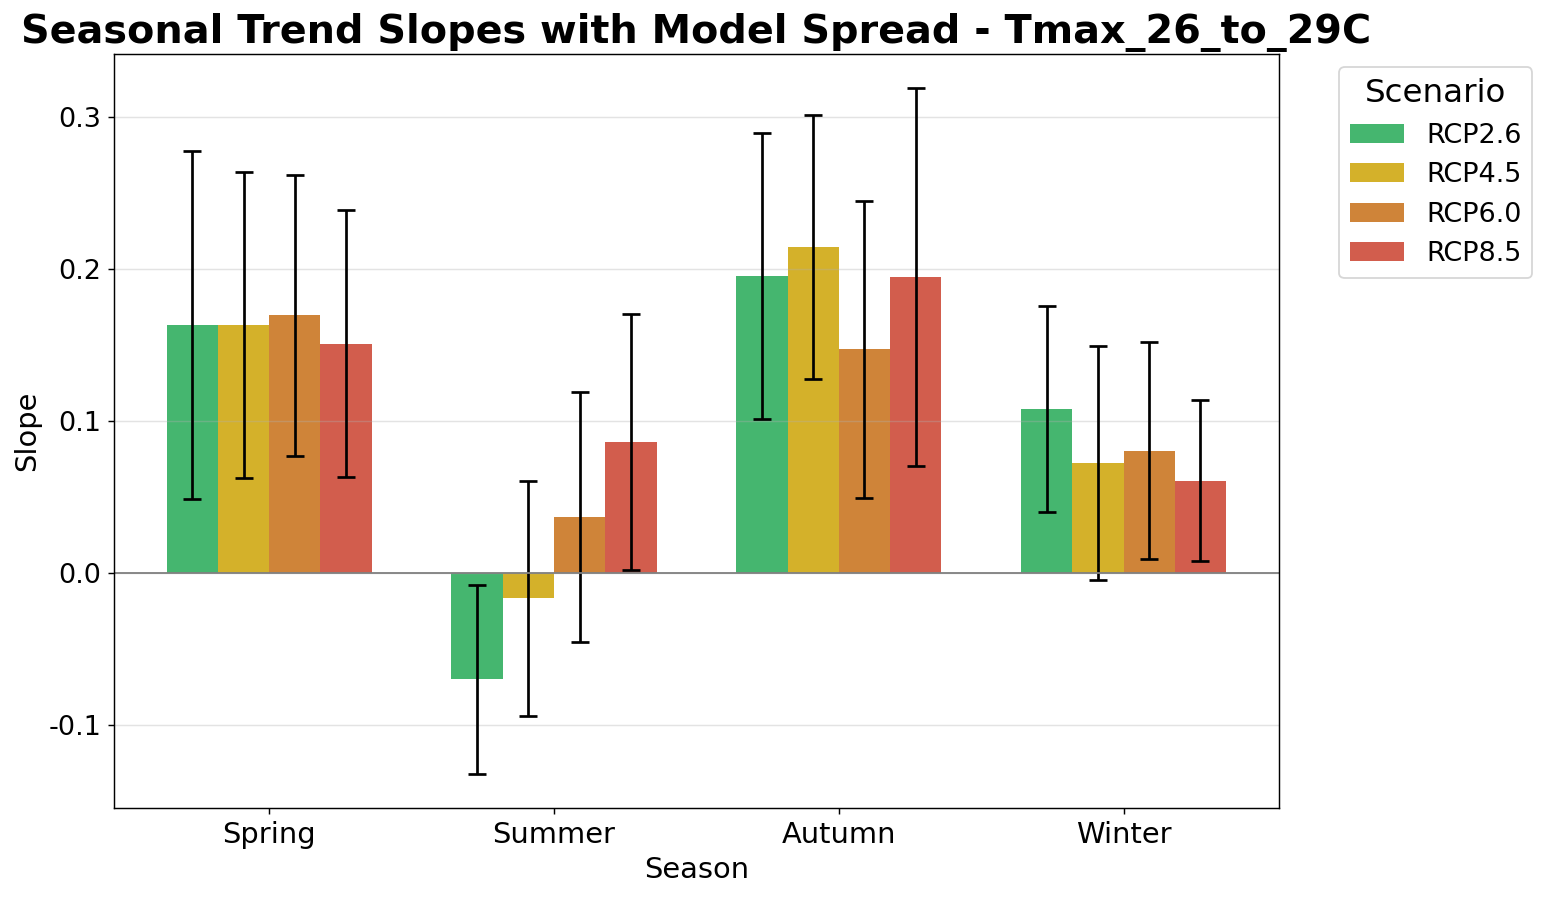

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmax_26_to_29C_seasonal_slope_boxplot.png


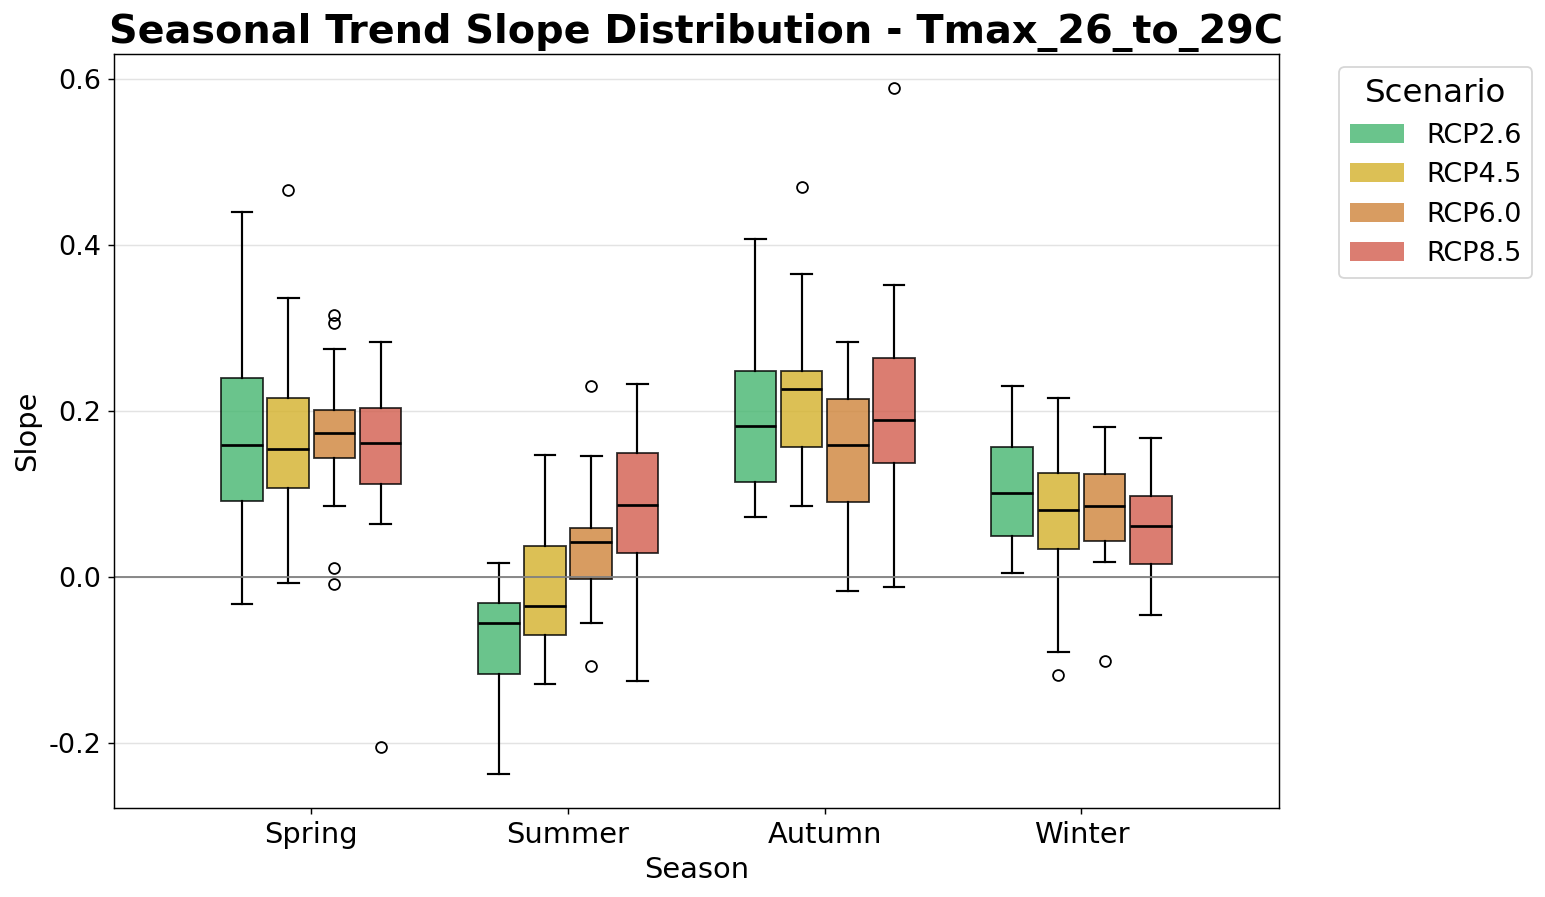

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmean_28_to_31C_seasonal_slope_errorbar.png


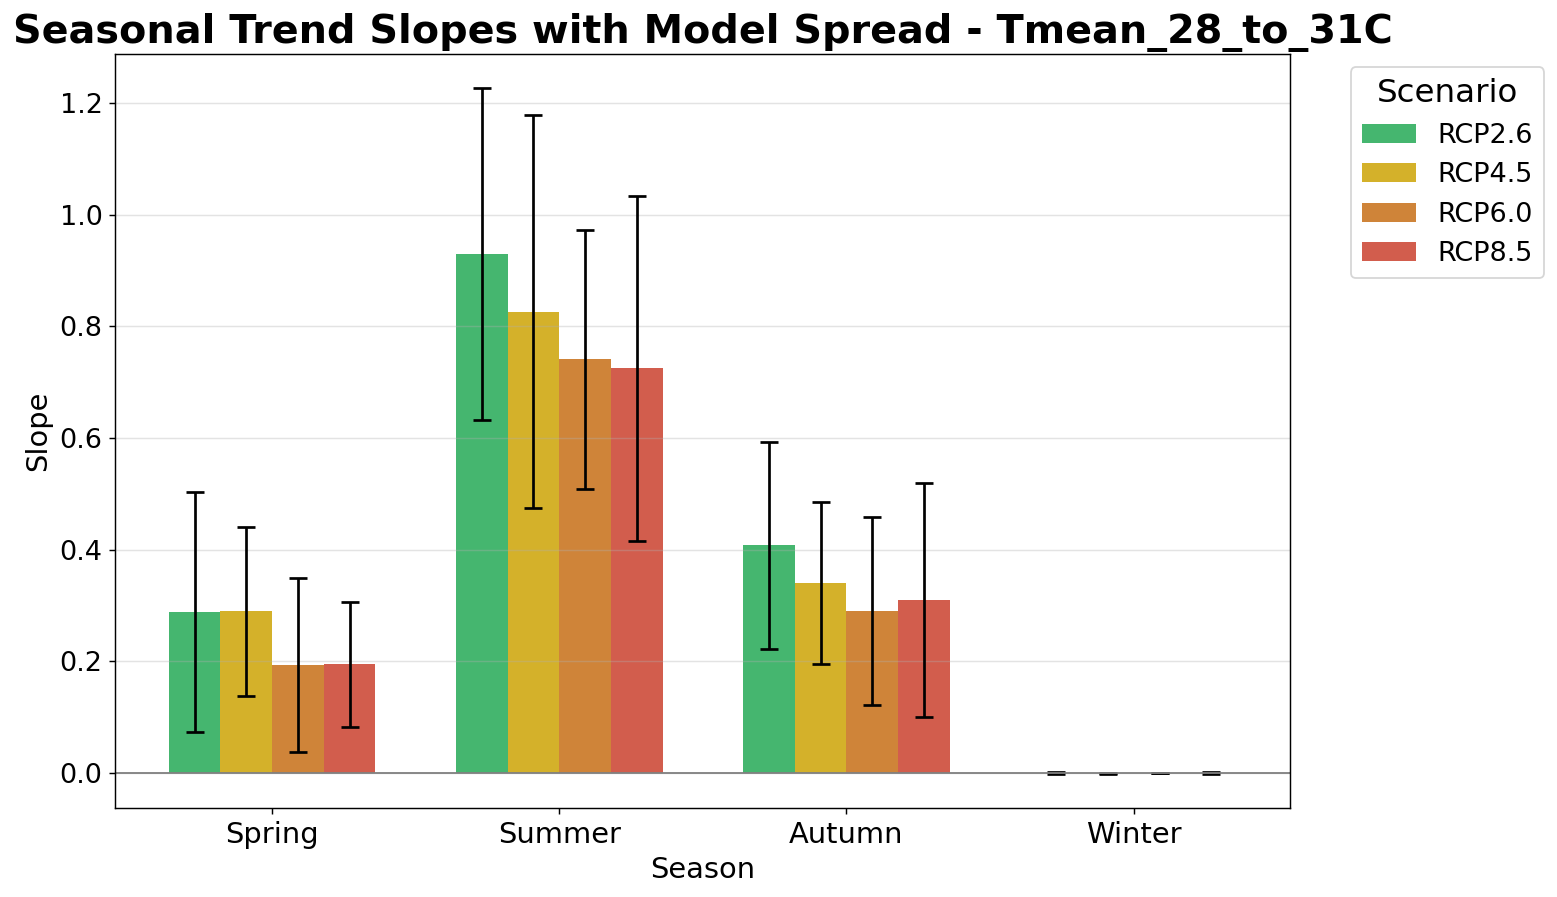

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmean_28_to_31C_seasonal_slope_boxplot.png


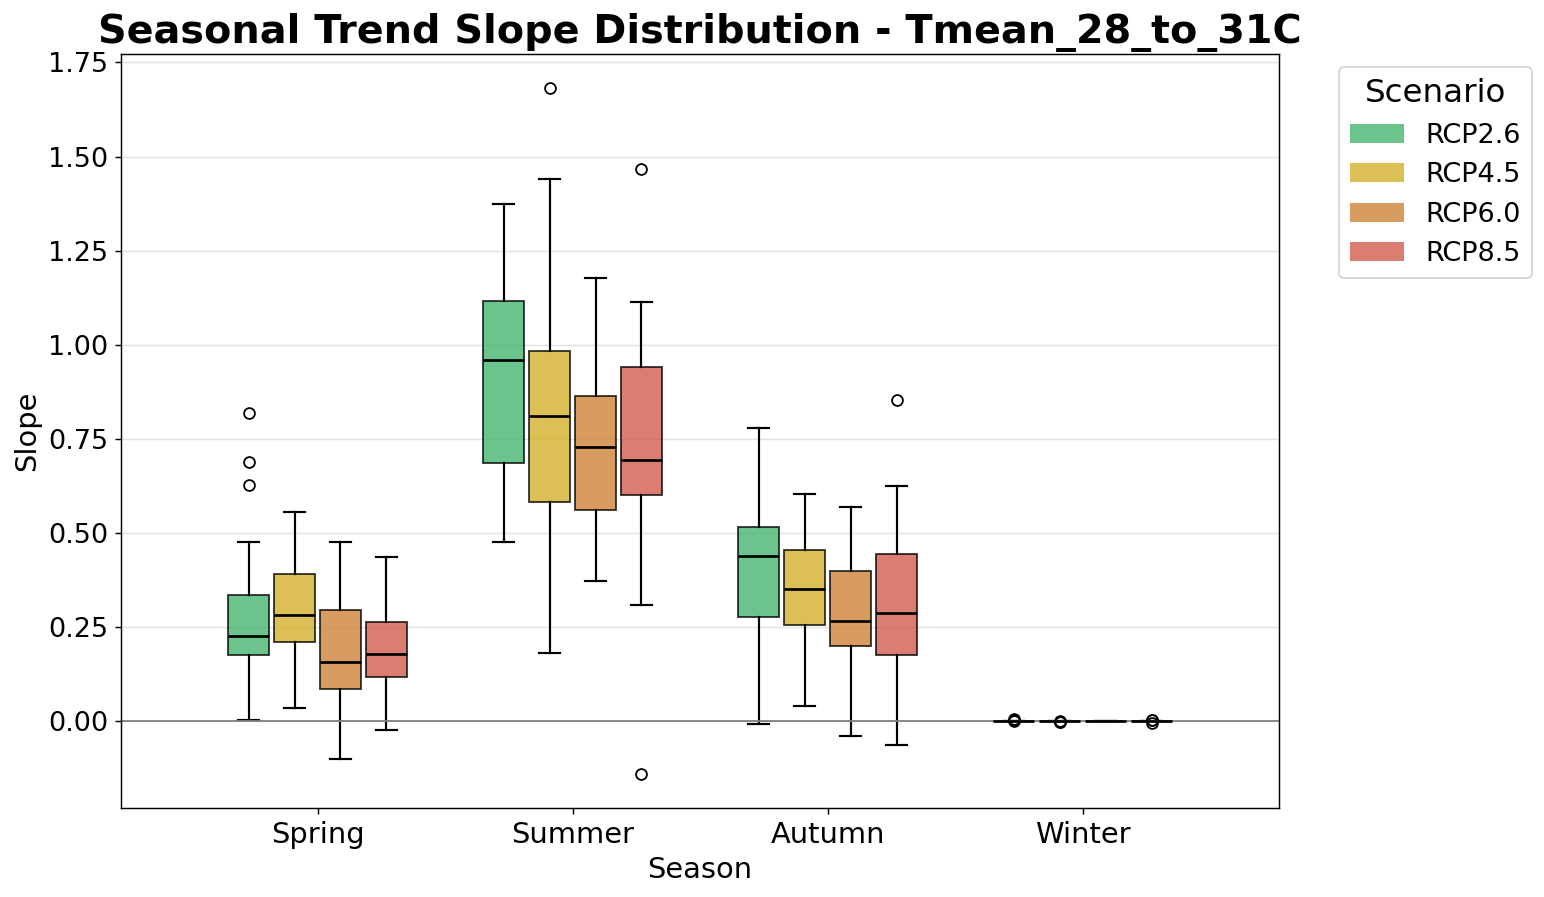

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmin_20_to_25C_seasonal_slope_errorbar.png


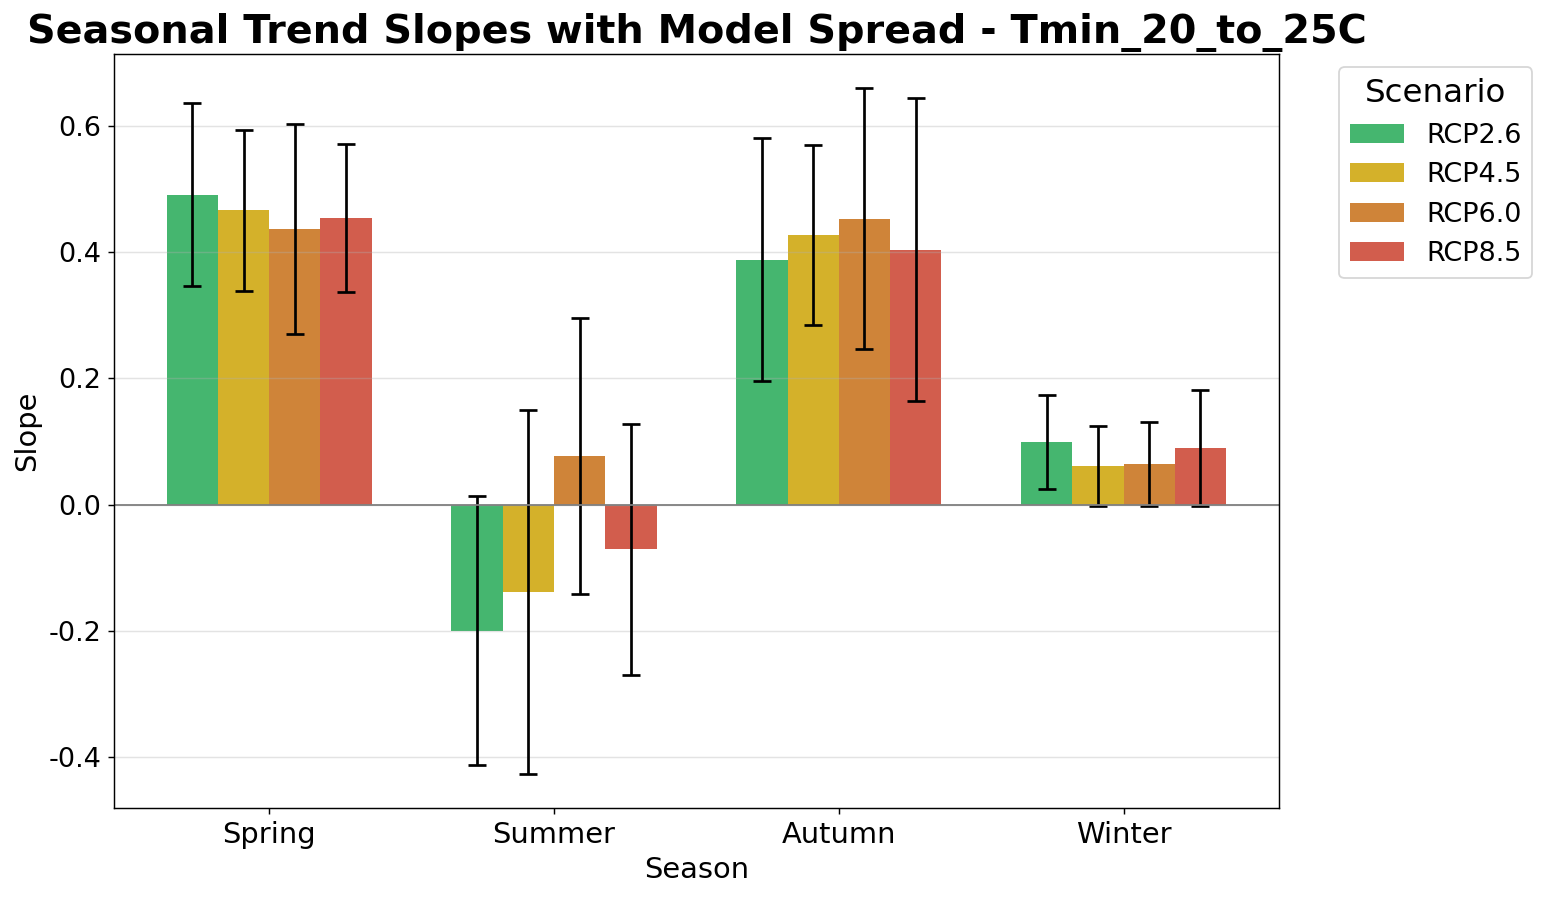

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmin_20_to_25C_seasonal_slope_boxplot.png


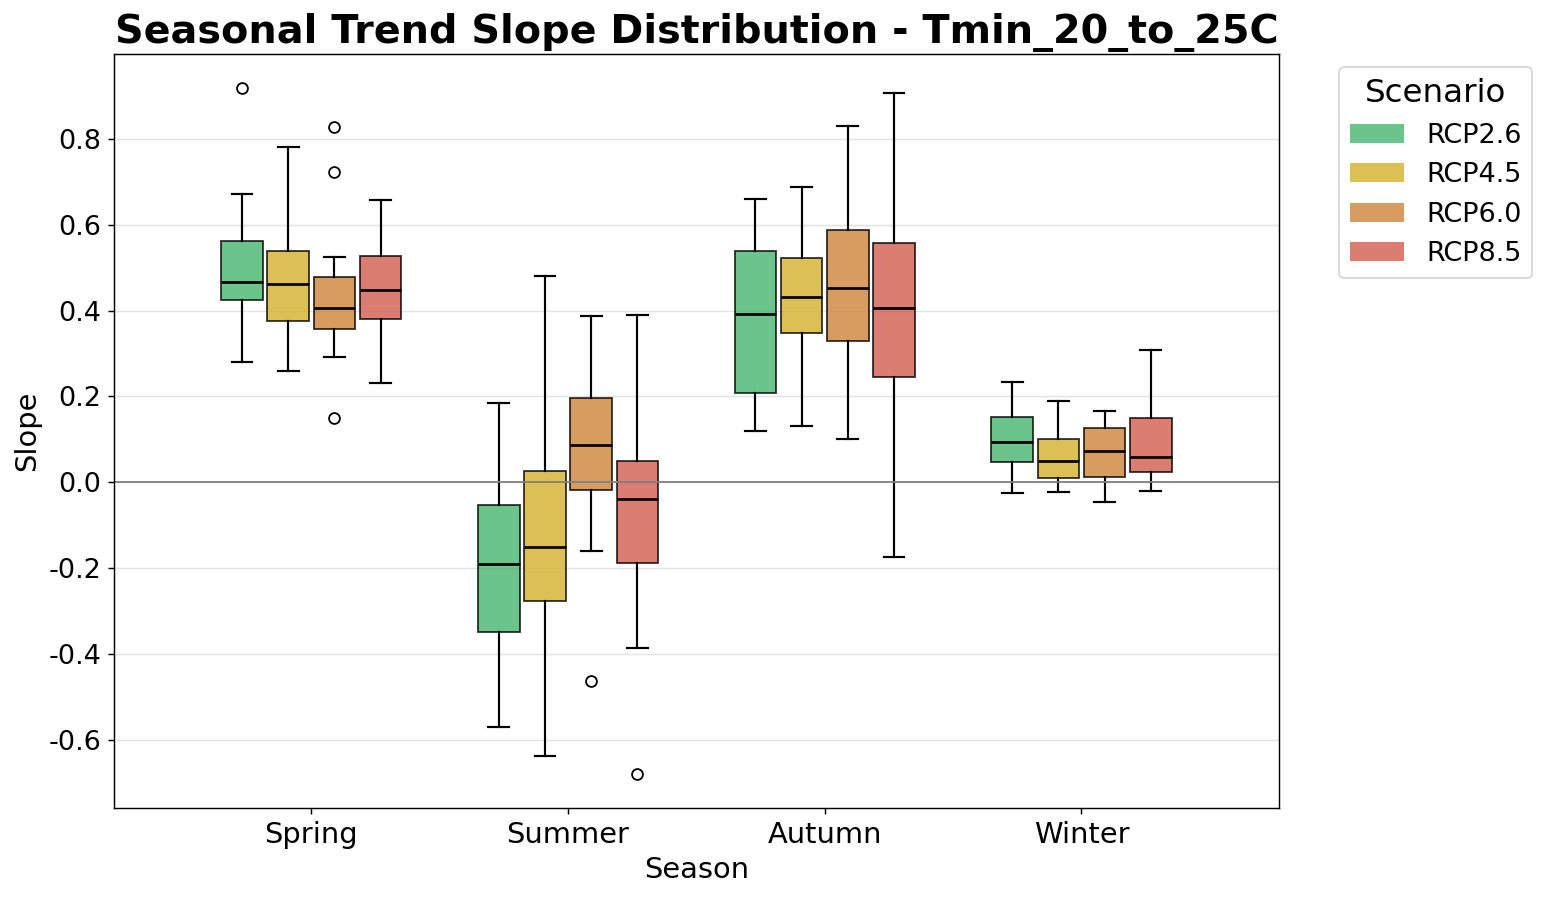

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmin_ge15_9C_seasonal_slope_errorbar.png


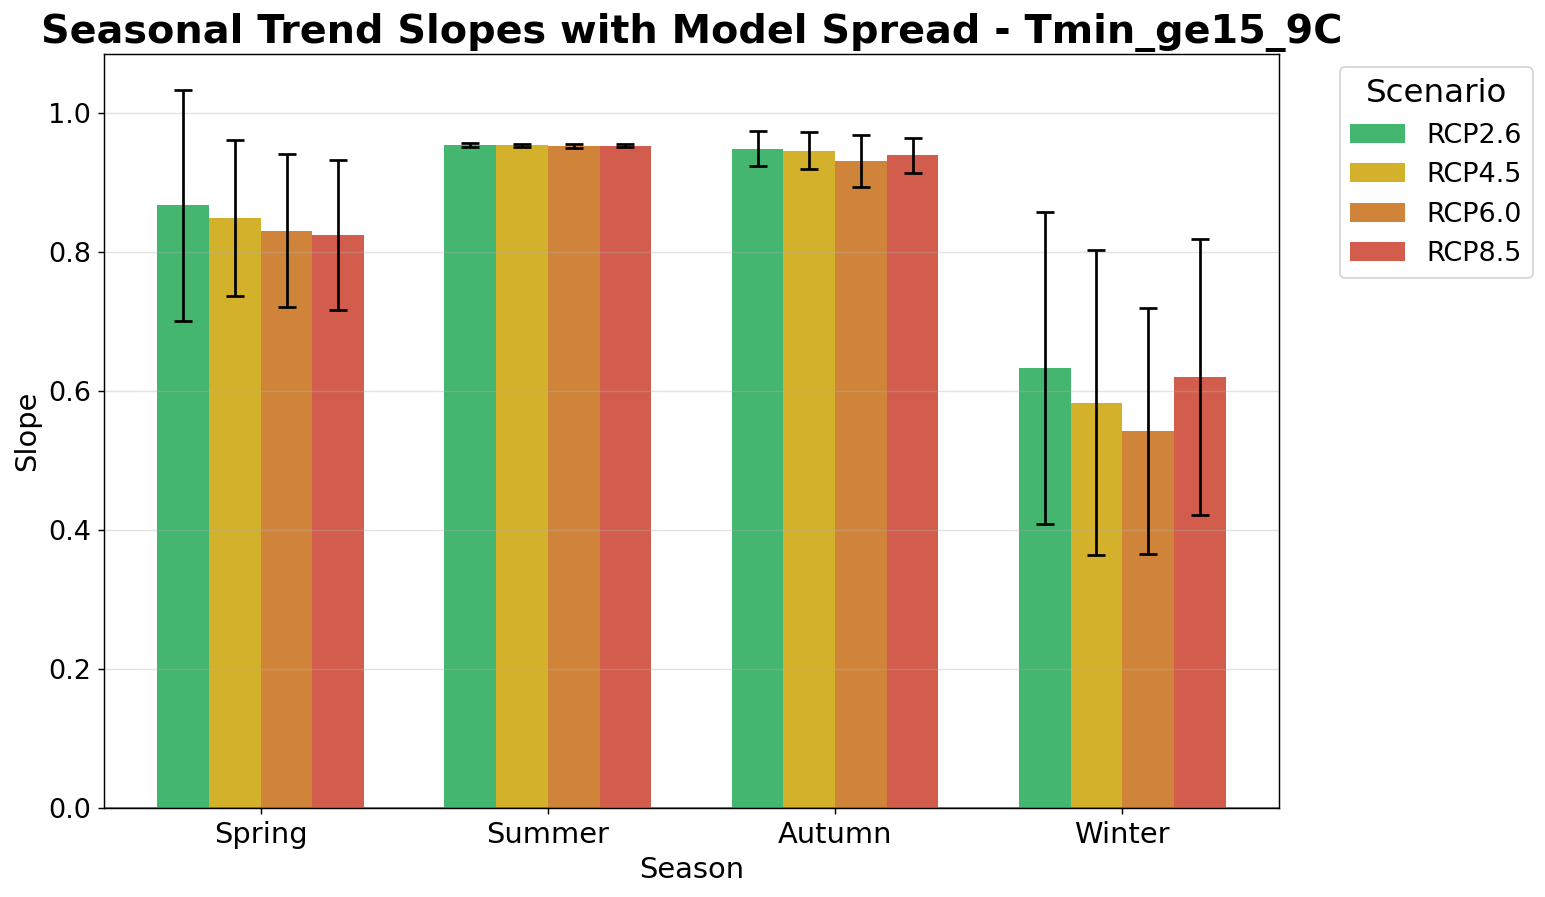

saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Tmin_ge15_9C_seasonal_slope_boxplot.png


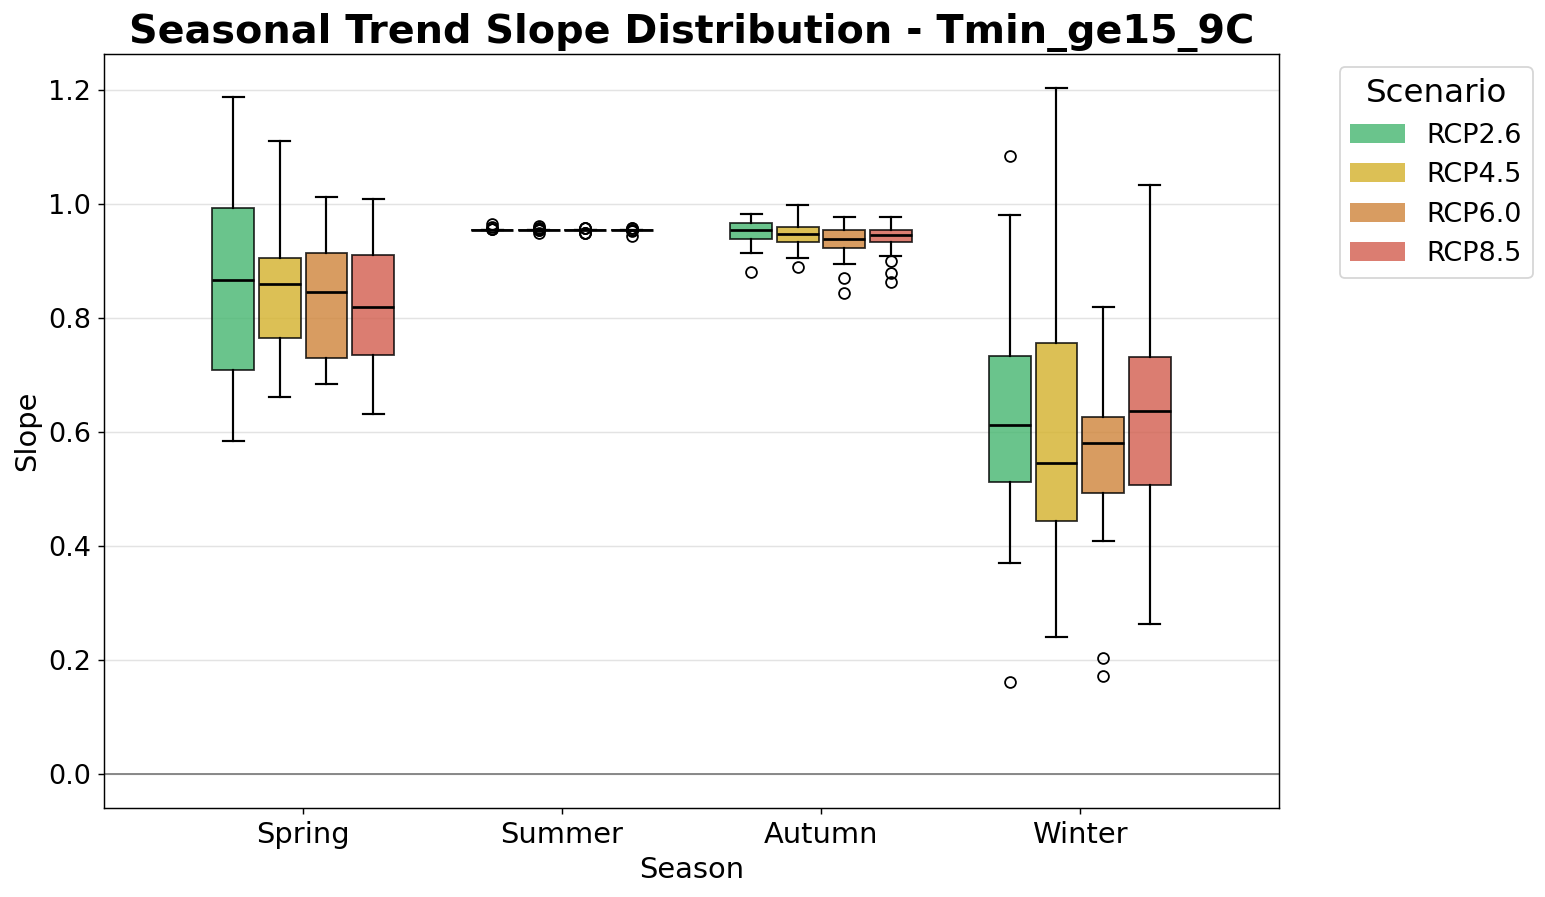

In [16]:
SAVE_DIR = r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue"

for combo in combo_defs:
    slope_mean_df, model_slope_df = calc_seasonal_slopes_for_combo(combo, df_map)

    plot_seasonal_slope_errorbar(
        slope_mean_df,
        model_slope_df,
        combo["title"],
        save_dir=SAVE_DIR
    )

    plot_seasonal_slope_boxplot(
        model_slope_df,
        combo["title"],
        save_dir=SAVE_DIR
    )
    